In [1]:
import os

if not os.path.exists('master.pkl'):
    print("cloning repo...")
    !git clone https://github.com/novodevz/ml_final_proj.git
    os.chdir('ml_final_proj')
    print("repo cloned succesfuly, current working dir:", os.getcwd())

# short task

In [1]:
import time
import joblib
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [9]:
RAND = 1

In [5]:
fashion_mnist = fetch_openml("Fashion-MNIST", version=1, as_frame=False)
X, y = fashion_mnist["data"], fashion_mnist["target"]
y = y.astype(int)
X = X / 255.0  
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=10000, shuffle=False)

### SVM

In [4]:
# svm

print("runnig svm with 10 fold CV ...")

svm_param_grid = {"C": [1, 10, 50], "gamma": ["scale"]}

base_svm = SVC()

grid_search_svm = GridSearchCV(
    estimator=base_svm,
    param_grid=svm_param_grid,
    cv=10,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1,
)

start_time = time.time()
grid_search_svm.fit(x_train, y_train)
svm_time = (time.time() - start_time) / 60

print(f"svm best parms: {grid_search_svm.best_params_}")
print(f"svm best 10 fold accuracy: {grid_search_svm.best_score_:.4f}")

best_svm = grid_search_svm.best_estimator_

svm_test_acc = best_svm.score(x_test, y_test)
print(f"svm test accuracy: {svm_test_acc:.4f}")
print(f'training time: {svm_time:.2f} mins')

svm_model_filename = "svm.joblib"
joblib.dump(best_svm, svm_model_filename, compress=3)

runnig svm with 10 fold CV ...
Fitting 10 folds for each of 3 candidates, totalling 30 fits
svm best parms: {'C': 10, 'gamma': 'scale'}
svm best 10 fold accuracy: 0.9060
svm test accuracy: 0.9002
training time: 111.16 mins


['svm.joblib']

### SVM Model Results

Fitting 10 folds for each of 3 candidates, totalling 30 fits results:  

svm best parms: {'C': 10, 'gamma': 'scale'}  
svm best 10 fold accuracy: 0.9060  
svm test accuracy: 0.9002  
training time: 111.16 mins  

#### Generalization
the small gap between the validation score (90.60%) and the test score (90.02%) shows that the model generalizes well to unseen data rather than "following the noise" or memorizing the training set.  

acheaving ~90% accuracy indicates that the RBF-kernel captures the complex, non-linear patterns across the different clothing classes quite effectively.

### run pre-trained svm model

In [5]:
import joblib
import sklearn

print('the model was trained on sklearn version 1.7.1')
print(f"you are running sklearn version: {sklearn.__version__}")

svm = joblib.load('svm.joblib')
svm_acc = svm.score(x_test, y_test)

print(f"svm model test accuracy: {svm_acc:.4f}")

the model was trained on sklearn version 1.7.1
you are running sklearn version: 1.7.1
svm model test accuracy: 0.9002


### random forest

In [6]:
# random forest (ensemble method)

print("running random forest with 10 fold CV ...")

rf_param_grid = {
    "n_estimators": [100, 200, 300], 
    "max_features": ["sqrt", 0.2]
}

base_rf = RandomForestClassifier(random_state=RAND)

grid_search_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=rf_param_grid,
    cv=10,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1,
)

start_time = time.time()
grid_search_rf.fit(x_train, y_train)
rf_time = (time.time() - start_time) / 60

print(f"rf best parms: {grid_search_rf.best_params_}")
print(f"rf best 10 fold accuracy: {grid_search_rf.best_score_:.4f}")

best_rf = grid_search_rf.best_estimator_

rf_test_acc = best_rf.score(x_test, y_test)
print(f"rf test set accuracy: {rf_test_acc:.4f}")
print(f'training time: {rf_time:.2f} mins')

rf_model_filename = "rf.joblib"
joblib.dump(best_rf, rf_model_filename, compress=3)

running random forest with 10 fold CV ...
Fitting 10 folds for each of 6 candidates, totalling 60 fits
rf best parms: {'max_features': 0.2, 'n_estimators': 300}
rf best 10 fold accuracy: 0.8869
rf test set accuracy: 0.8815
training time: 321.75 mins


['rf.joblib']

### Random Forest Model Results

Fitting 10 folds for each of 6 candidates, totalling 60 fits results:  

rf best parms: {'max_features': 0.2, 'n_estimators': 300}  
rf best 10 fold accuracy: 0.8869  
rf test set accuracy: 0.8815  
training time: 321.75 mins  

#### Generalization
the small gap between CV accuracy (88.69%) and test accuracy (88.15%) indicates low variance and solid generalization to unseen images.
`max_features=0.2` forces each split to consider only 20% of random pixel features (~156 out of 784). This decorrelates individual trees, preventing dominant background pixels from biasing the entire ensemble.

### run pre-trained rf

In [8]:
import joblib
import sklearn

print('the model was trained on sklearn version 1.7.1')
print(f"you are running sklearn version: {sklearn.__version__}")

rf = joblib.load('rf.joblib')
rf_acc = rf.score(x_test, y_test)

print(f"rf model test accuracy: {rf_acc:.4f}")

the model was trained on sklearn version 1.7.1
you are running sklearn version: 1.7.1
rf model test accuracy: 0.8815


### SVM vs. Random Forest

while random forest performed well (with test acc: ~88.15%), the RBF-kernel SVM outperformed it (test acc: ~90.02%).

random forest splits data using axis-aligned cuts on single pixels, which struggles to neatly outline diagonal lines and smooth curves in clothing items resulting in low decision boundary flexibility. on the other hand, RBF-SVM measures overall image similarity across all pixels simultaneously, allowing it to draw smooth, flexible boundaries that naturally capture complex shapes like sleeves, collars, and shoe outlines, allowing better overall pattern recognition and smoother decision boundaries.

### PCA

In [6]:
import time
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [7]:
def analyze_pca_variance(x_train, target_thresholds=(0.80, 0.90), max_plot_components=150, random_state=42):
    pca = PCA(random_state=random_state).fit(x_train)
    evr = pca.explained_variance_ratio_
    cum_var = np.cumsum(evr)

    plt.figure(figsize=(8, 4.5))
    plt.plot(range(1, len(cum_var) + 1), cum_var, lw=2, label='Cumulative Variance')
    plt.bar(range(1, len(evr) + 1), evr, color='gray', label='Individual Variance')

    colors = ['purple', 'green', 'red']
    styles = ['--', '-.', ':']

    threshold_components = {}
    for i, target in enumerate(target_thresholds):
        n_comps = np.argmax(cum_var >= target) + 1
        threshold_components[target] = n_comps
        
        # color = colors[i % len(colors)]
        style = styles[i % len(styles)]
        
        plt.axvline(x=n_comps, color='gray', linestyle=style, alpha=0.8, 
                    label=f'{int(target*100)}% Var ({n_comps} PCs)')

    plt.xlim(0, min(max_plot_components, len(evr)))
    plt.ylim(0, 1.05)
    plt.title("PCA Scree Plot")
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca, threshold_components

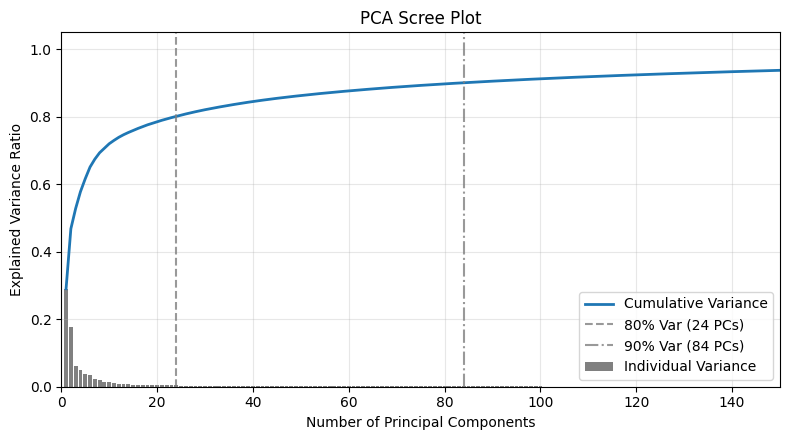

In [10]:
pca, thresholds = analyze_pca_variance(x_train, random_state=RAND)

In [11]:
for k, v in thresholds.items():
    print(k, v)

0.8 24
0.9 84


### PCA Variance Analysis

In [19]:
evr = pca.explained_variance_ratio_
cum_var = np.cumsum(evr)

qtr_pcs = len(evr) // 4
cum_var_qtr = cum_var[qtr_pcs - 1]

hlf_pcs = len(evr) // 2
cum_var_half = cum_var[hlf_pcs - 1]

targets = [0.80, 0.90, 0.99]
thresholds = {}

for target in targets:
    n_pcs = int(np.argmax(cum_var >= target) + 1)
    exact_var = cum_var[n_pcs - 1]
    thresholds[target] = (n_pcs, exact_var)

n_comp_80, var_80 = thresholds[0.80]
n_comp_90, var_90 = thresholds[0.90]
n_comp_99, var_99 = thresholds[0.99]

print(f"Variance captured by PC1: {evr[0]:.4f} ({evr[0]*100:.2f}%)")
print(f"Cumulative variance captured by PC1 + PC2: {cum_var[1]:.4f} ({cum_var[1]*100:.2f}%)")
print(f"Cumulative variance captured by quarter of PCs ({qtr_pcs} PCs): {cum_var_qtr:.4f} ({cum_var_qtr*100:.2f}%)")
print(f"Cumulative variance captured by half of PCs ({hlf_pcs} PCs): {cum_var_half:.4f} ({cum_var_half*100:.2f}%)")
print(f"80% Variance Target: {n_comp_80} PCs (Exact Captured: {var_80:.4f} / {var_80*100:.2f}%)")
print(f"90% Variance Target: {n_comp_90} PCs (Exact Captured: {var_90:.4f} / {var_90*100:.2f}%)")
print(f"99% Variance Target: {n_comp_99} PCs (Exact Captured: {var_99:.4f} / {var_99*100:.2f}%)")

Variance captured by PC1: 0.2904 (29.04%)
Cumulative variance captured by PC1 + PC2: 0.4679 (46.79%)
Cumulative variance captured by quarter of PCs (196 PCs): 0.9526 (95.26%)
Cumulative variance captured by half of PCs (392 PCs): 0.9846 (98.46%)
80% Variance Target: 24 PCs (Exact Captured: 0.8011 / 80.11%)
90% Variance Target: 84 PCs (Exact Captured: 0.9006 / 90.06%)
99% Variance Target: 459 PCs (Exact Captured: 0.9900 / 99.00%)


### PCA Variance Analysis output

Variance captured by PC1: 0.2904 (29.04%)  
Cumulative variance captured by PC1 + PC2: 0.4679 (46.79%)  
Cumulative variance captured by quarter of PCs (196 PCs): 0.9526 (95.26%)  
Cumulative variance captured by half of PCs (392 PCs): 0.9846 (98.46%)  
80% Variance Target: 24 PCs (Exact Captured: 0.8011 / 80.11%)  
90% Variance Target: 84 PCs (Exact Captured: 0.9006 / 90.06%)  
99% Variance Target: 459 PCs (Exact Captured: 0.9900 / 99.00%)  

### PCA image reconstruction

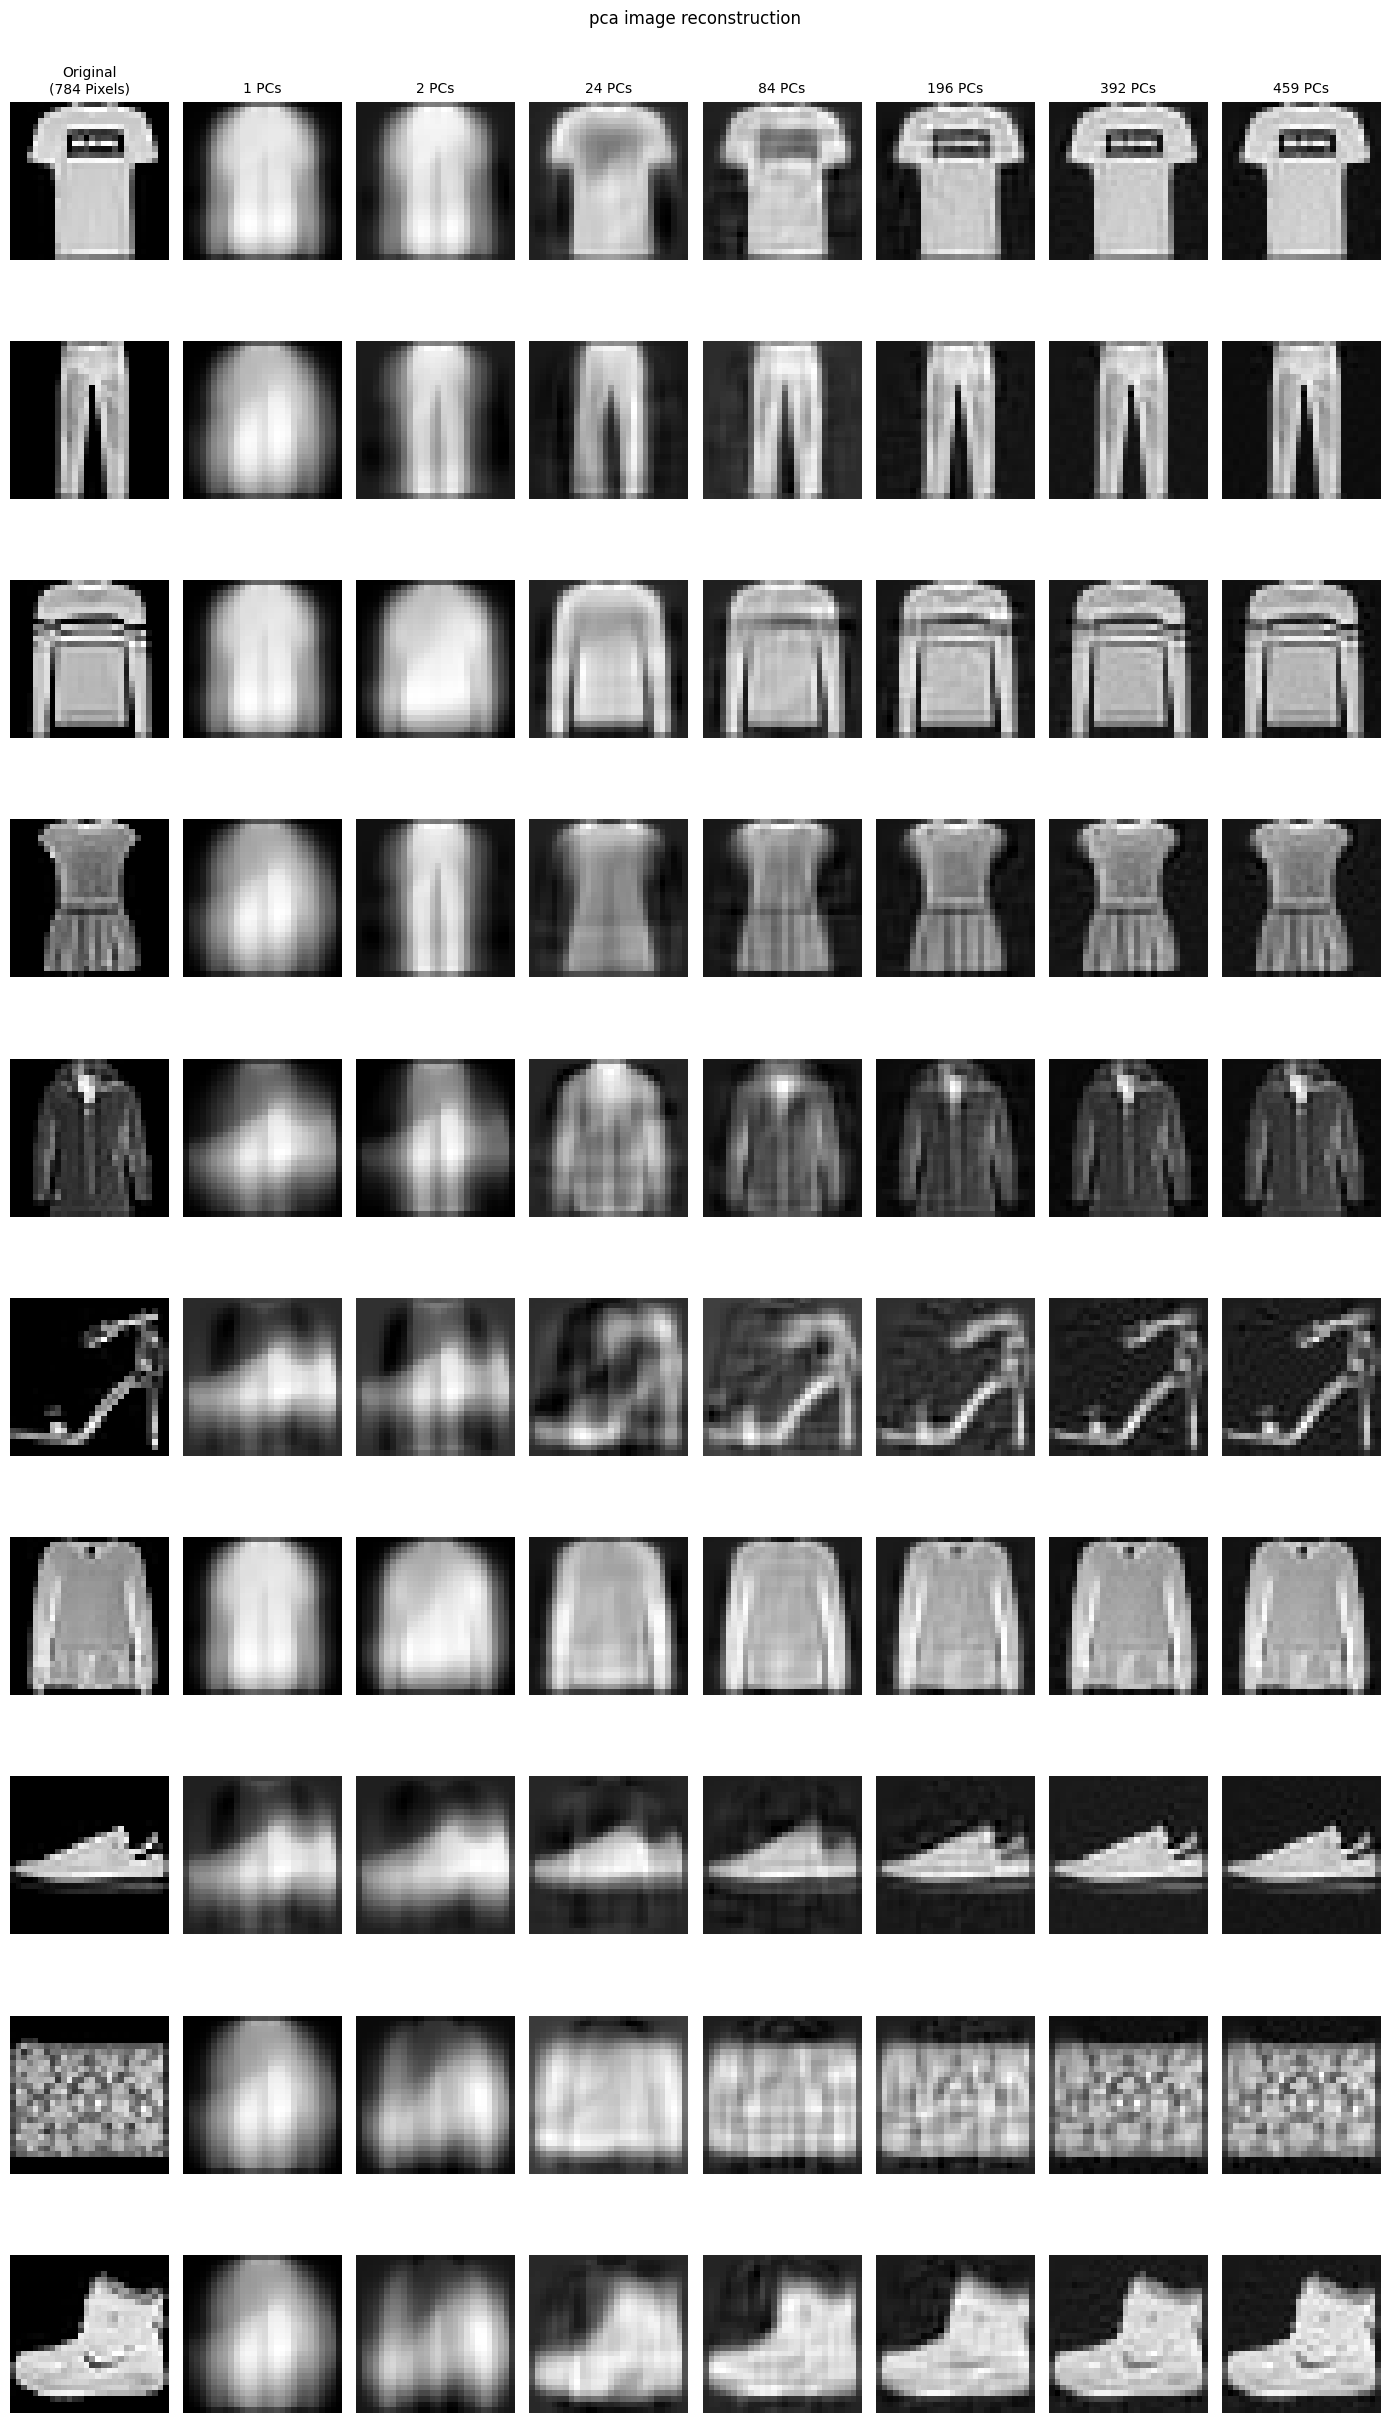

In [21]:
unique_classes = np.unique(y_train)
sample_indices = [np.where(y_train == cls)[0][0] for cls in unique_classes]
# sample_indices = [np.argmax(y_train == cls) for cls in unique_classes]

pc_thresholds = [1, 2, n_comp_80, n_comp_90, qtr_pcs, hlf_pcs, n_comp_99]

fig, axes = plt.subplots(len(sample_indices), len(pc_thresholds) + 1, figsize=(14, 2.5 * len(sample_indices)), squeeze=False)

for row_idx, img_idx in enumerate(sample_indices):
    orig_img = x_train[img_idx].reshape(28, 28)
    axes[row_idx, 0].imshow(orig_img, cmap='gray')
    if row_idx == 0:
        axes[row_idx, 0].set_title("Original\n(784 Pixels)", fontsize=10)
    axes[row_idx, 0].axis('off')

for col_idx, n_pcs in enumerate(pc_thresholds):
    pca_test = PCA(n_components=n_pcs, random_state=RAND)
    x_train_compressed = pca_test.fit_transform(x_train)
    
    x_train_reconstructed = pca_test.inverse_transform(x_train_compressed[sample_indices])

    for row_idx in range(len(sample_indices)):
        reconstructed_img = x_train_reconstructed[row_idx].reshape(28, 28)
        axes[row_idx, col_idx + 1].imshow(reconstructed_img, cmap='gray')
        if row_idx == 0:
            axes[row_idx, col_idx + 1].set_title(f"{n_pcs} PCs", fontsize=10)
        axes[row_idx, col_idx + 1].axis('off')

plt.suptitle("pca image reconstruction", fontsize=12, y=0.99)
plt.tight_layout()
plt.show()

### Reconstruction Quality & Visual Clarity

comparing the original 28*28 images with their reconstructed counterparts across different principal component count: PCs 1-2 (almost 50% of the cumulative explained variance) are kind of ghosts blurry images, failing to represent the true class. it looks like they mostly capture contrust between the black background and the wite pixels of the fashion items. another big variance portion capture by PCs 1-2 looks to be vertical vs. horizontal orientation.  

24 PCs (80% variance) succefully display the true class item and are clearly distinguishable but still very blury, and fine details are heavily blurred.  

392 PCs that makes half of the dimentionality (98.46% variance) fine details like the niky logo or the purse texture become sharper.

459 PCs (99.00% variance) it is already hard for me to tell the diff between this and the original images.

conclusion: even though pixel space is not lineary related, PCA is still very powerfull. reducing the dimentions from 784 to 459 and getting almost the same image quality as the original is a big win with very litle price to pay on the image quality. more over, accurate classification (meaning to just recognize the item and its category) is acheaved with masive dimentionality reduction from 784 to just 24 PCs.

# main assignment

In [274]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [275]:
df_master = pd.read_pickle("master.pkl")

print(f"Dataset shape: {df_master.shape}")
df_master.head()

Dataset shape: (83, 31)


,File.Name,Region.of.Interest,Number.of.Root.Tips,Number.of.Branch.Points,Total.Root.Length.mm,Branching.frequency.per.mm,Network.Area.mm2,Average.Diameter.mm,Median.Diameter.mm,Maximum.Diameter.mm,Perimeter.mm,Volume.mm3,Surface.Area.mm2,Computation.Time.s,Root.Length.Diameter.Range.1.mm,Root.Length.Diameter.Range.2.mm,Root.Length.Diameter.Range.3.mm,Root.Length.Diameter.Range.4.mm,Projected.Area.Diameter.Range.1.mm2,Projected.Area.Diameter.Range.2.mm2,Projected.Area.Diameter.Range.3.mm2,Projected.Area.Diameter.Range.4.mm2,Surface.Area.Diameter.Range.1.mm2,Surface.Area.Diameter.Range.2.mm2,Surface.Area.Diameter.Range.3.mm2,Surface.Area.Diameter.Range.4.mm2,Volume.Diameter.Range.1.mm3,Volume.Diameter.Range.2.mm3,Volume.Diameter.Range.3.mm3,Volume.Diameter.Range.4.mm3,target
0,sensor_01.jpg,Full,1304,16633,17856.509706,0.931481,5674.850657,0.555205,0.359210,7.393199,23418.652929,8919.576845,30860.026312,4.732,9538.421481,4887.040800,2471.356816,959.690609,2168.626958,2766.273322,2637.760618,2247.621870,6813.991328,8692.921282,8289.781721,7063.331980,443.719786,1281.222991,2281.108963,4913.525105,aq
1,sensor_02.jpg,Full,1239,13513,14179.577443,0.952990,5311.914107,0.679813,0.478947,7.130622,17850.034901,10590.247853,30218.088704,4.519,6105.782918,4258.773914,2627.723452,1187.297159,1419.649093,2470.469693,2819.877500,2906.068688,4461.306400,7762.757680,8861.344722,9132.679902,297.309254,1171.483202,2453.418298,6668.037099,aq
2,sensor_03.jpg,Full,1464,21269,18530.549154,1.147780,6304.408538,0.661123,0.431717,9.393041,21899.722838,14627.572701,38547.956326,5.402,8496.004519,5537.207049,2915.051459,1582.286127,1969.987954,3143.234825,3129.404111,4022.072301,6192.099877,9878.967617,9836.715850,12640.172983,411.512787,1459.769342,2725.168447,10031.122125,aq
3,sensor_04.jpg,Full,1398,16392,17199.251661,0.953065,5533.456675,0.597465,0.378641,9.237983,21896.761780,11149.125285,32129.013266,6.071,8794.705562,4635.119092,2624.301752,1145.125255,1925.144031,2622.195942,2839.772592,2836.795170,6049.400684,8240.432010,8925.305368,8913.875205,384.830732,1212.974803,2488.838258,7062.481492,aq
4,sensor_05.jpg,Full,1054,13355,14630.499214,0.912819,5098.235323,0.614277,0.431717,5.975452,18636.096938,8509.048353,28099.398618,4.920,6756.957638,4492.357708,2474.145956,907.037912,1587.573910,2609.645043,2635.188715,2109.761794,4987.984519,8200.664440,8281.133455,6629.616204,331.522060,1238.943855,2273.460810,4665.121627,aq


### EDA | target maping

In [276]:
df_master['target'] = df_master['target'].map({'ori': 0, 'aq': 1, })
df_master['target'].value_counts()

target
1    43
0    40
Name: count, dtype: int64

### EDA | missing values check

In [277]:
missing_vals = df_master.isna().sum().sum()
missing_vals

np.int64(0)

### EDA | drop meta data cols, assign X y

In [278]:
metadata_cols = ["File.Name", "Region.of.Interest", "Computation.Time.s"]
range_4_cols = [col for col in df_master.columns if "Range.4" in col]
cols_to_drop = metadata_cols + range_4_cols + ["target"]

X = df_master.drop(columns=cols_to_drop, errors="ignore")
y = df_master["target"]

X.shape, y.shape

((83, 23), (83,))

In [279]:
for c in X.columns:
    print(c)

Number.of.Root.Tips
Number.of.Branch.Points
Total.Root.Length.mm
Branching.frequency.per.mm
Network.Area.mm2
Average.Diameter.mm
Median.Diameter.mm
Maximum.Diameter.mm
Perimeter.mm
Volume.mm3
Surface.Area.mm2
Root.Length.Diameter.Range.1.mm
Root.Length.Diameter.Range.2.mm
Root.Length.Diameter.Range.3.mm
Projected.Area.Diameter.Range.1.mm2
Projected.Area.Diameter.Range.2.mm2
Projected.Area.Diameter.Range.3.mm2
Surface.Area.Diameter.Range.1.mm2
Surface.Area.Diameter.Range.2.mm2
Surface.Area.Diameter.Range.3.mm2
Volume.Diameter.Range.1.mm3
Volume.Diameter.Range.2.mm3
Volume.Diameter.Range.3.mm3


### EDA | non numeric values check

In [280]:
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()
non_numeric_cols

[]

In [281]:
# X.describe()

In [282]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Number.of.Root.Tips                  83 non-null     int64  
 1   Number.of.Branch.Points              83 non-null     int64  
 2   Total.Root.Length.mm                 83 non-null     float64
 3   Branching.frequency.per.mm           83 non-null     float64
 4   Network.Area.mm2                     83 non-null     float64
 5   Average.Diameter.mm                  83 non-null     float64
 6   Median.Diameter.mm                   83 non-null     float64
 7   Maximum.Diameter.mm                  83 non-null     float64
 8   Perimeter.mm                         83 non-null     float64
 9   Volume.mm3                           83 non-null     float64
 10  Surface.Area.mm2                     83 non-null     float64
 11  Root.Length.Diameter.Range.1.mm   

### data split

In [314]:
RAND=99

In [315]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RAND, stratify=y
)

### data scaling

In [316]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"Scaled Train shape: {X_train_scaled.shape}")
print(f"Scaled Test shape:  {X_test_scaled.shape}")

Scaled Train shape: (66, 23)
Scaled Test shape:  (17, 23)


### PCA

In [317]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

def analyze_pca_variance(x_train, target_thresholds=(0.80, 0.90), max_plot_components=23):
    pca = PCA(random_state=RAND).fit(x_train)
    evr = pca.explained_variance_ratio_
    cum_var = np.cumsum(evr)

    plt.figure(figsize=(8, 4.5))
    plt.plot(range(1, len(cum_var) + 1), cum_var, lw=2, label='Cumulative Variance')
    plt.bar(range(1, len(evr) + 1), evr, color='gray', label='Individual Variance')

    colors = ['purple', 'green', 'red', 'pink']
    styles = ['--', '-.', ':', '-']

    threshold_components = {}
    for i, target in enumerate(target_thresholds):
        n_comps = np.argmax(cum_var >= target) + 1
        threshold_components[target] = n_comps
        
        # color = colors[i % len(colors)]
        style = styles[i % len(styles)]
        
        plt.axvline(x=n_comps, color='gray', linestyle=style, alpha=0.8, 
                    label=f'{float(target*100)}% Var ({n_comps} PCs)')

    plt.xlim(0, min(max_plot_components, len(evr)))
    plt.ylim(0, 1.05)
    plt.title("PCA Scree Plot")
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.legend(loc='lower right')
    # plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca, threshold_components

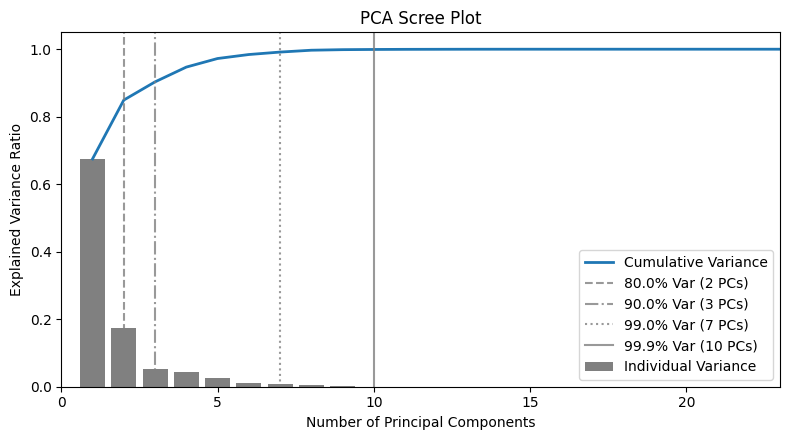

PCA Thresholds:
80.0% explained variance captured by 2 components
90.0% explained variance captured by 3 components
99.0% explained variance captured by 7 components
99.9% explained variance captured by 10 components


In [318]:
pca, pca_thresholds = analyze_pca_variance(
    X_train_scaled, target_thresholds=(0.80, 0.90, 0.99, 0.999)
)

print("PCA Thresholds:")
for k, v in pca_thresholds.items():
  print(
      f"{float(k*100)}% explained variance captured by {v} components"
  )

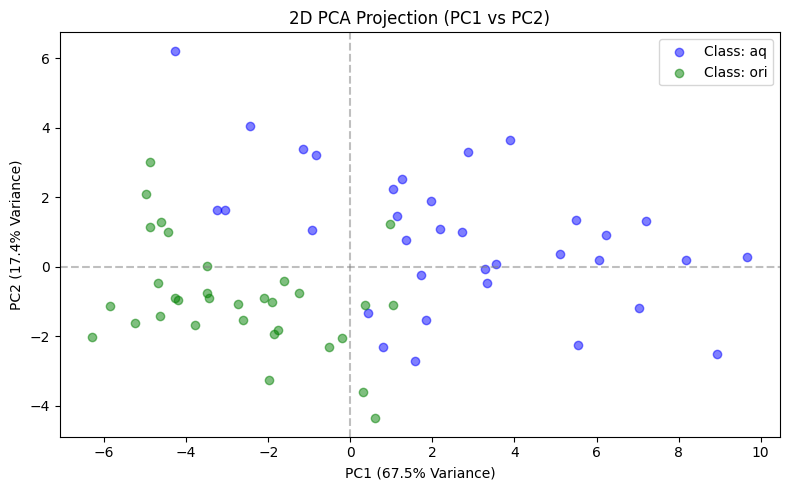

In [319]:
# 1. Project training data onto the first 2 principal components
X_pca_2d = pca.transform(X_train_scaled)[:, :2]

# 2. Create DataFrame for plotting
df_pca = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca['Target'] = y_train.values

# 3. Scatter plot
plt.figure(figsize=(8, 5))
for label, color, name in zip([1, 0], ['blue', 'green'], ['aq', 'ori']):
    subset = df_pca[df_pca['Target'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], c=color, label=f'Class: {name}', alpha=0.5)

plt.title('2D PCA Projection (PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.legend()
# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### PCA feature loading analysis
the biological insight of PC1-3

In [320]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_[:3, :],
    columns=X_train.columns,
    index=['PC1', 'PC2', 'PC3'],
).T

for pc in ['PC1', 'PC2', 'PC3']:
    print(f"=== Top Features driving {pc} ===")
    top_feats = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(loadings.loc[top_feats.index, pc],)
    print()

=== Top Features driving PC1 ===
Total.Root.Length.mm           0.250009
Network.Area.mm2               0.249546
Number.of.Branch.Points        0.246274
Surface.Area.mm2               0.245637
Volume.Diameter.Range.2.mm3    0.237762
Name: PC1, dtype: float64

=== Top Features driving PC2 ===
Average.Diameter.mm                    0.426749
Volume.Diameter.Range.1.mm3           -0.364711
Median.Diameter.mm                     0.335313
Projected.Area.Diameter.Range.1.mm2   -0.317607
Surface.Area.Diameter.Range.1.mm2     -0.317320
Name: PC2, dtype: float64

=== Top Features driving PC3 ===
Maximum.Diameter.mm                    0.439227
Number.of.Root.Tips                   -0.383270
Root.Length.Diameter.Range.2.mm       -0.379894
Projected.Area.Diameter.Range.2.mm2   -0.304431
Surface.Area.Diameter.Range.2.mm2     -0.302279
Name: PC3, dtype: float64



### PCA discussion

67.5% explained variance captured by PC1 alone

80.0% explained variance captured by 2 components
90.0% explained variance captured by 3 components
99.0% explained variance captured by 7 components
99.9% explained variance captured by 10 components

PCA apears to be highly efficient on this problem. the data looks lineary seperable already when ploting on 2D using just 80% of the explained variance, as most of the seperation is along PC1 axis capturing 67.5% of the explianed variance. next, with 3-7 the model acheaved 90-99% of the explained variance.  

reducing dimentionality from 23 original features to 3-7 components capturing 90-99% of the variance shows that many of the features in this data set are lineary related and essensionaly holding redundent information. this adds complexcity and may lead to future overfitting. by reducing dimentionality on this problem, PCA not only follows the parsimony principal of ahceaving high preformence with lighter model, but also mitigating the course of dimentionality problem X.shape => (83, 23). given the above analysis, passing PCA to models pipline on this problem will improve generalizability.

PC1 captures overall root system expansion, separating the two rootstocks based on total length, area, and branching density. PC2 and PC3 reflect structural trade offs, such as root thickness relative to finer feeder roots and anchor diameter versus active tip proliferation. because most of the class separation is aligned with PC1 (which accounts for 67.5% of total variance), the fundamental morphological distinction between the rootstocks is simply total root network size.

### Classification | logistic regression

In [321]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def run_lg(prm_grd: dict, rnd: int):

    logreg_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=rnd)),
        (
            'logreg',
            LogisticRegression(
                solver='saga', max_iter=1000, tol=0.0005, random_state=rnd
            ),
        ),
    ])
    
    cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=rnd)
    
    grid_search_logreg = GridSearchCV(
        estimator=logreg_pipeline,
        param_grid=prm_grd,
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=-1,
        return_train_score=True,
    )
    
    grid_search_logreg.fit(X_train, y_train)
    
    # Best Model Results
    best_logreg = grid_search_logreg.best_estimator_
    
    print("=== Best Logistic Regression Hyperparameters ===")
    for param, val in grid_search_logreg.best_params_.items():
      print(f"{param}: {val}")
    
    print(f"\nBest 10-Fold CV Accuracy: {grid_search_logreg.best_score_:.4f}")
    
    # Evaluate Best Model on Held-Out Test Set
    y_pred_logreg = best_logreg.predict(X_test)
    
    test_acc_lr = accuracy_score(y_test, y_pred_logreg)
    
    print("\n=== Final Test Set Evaluation (Logistic Regression) ===")
    print(f"Test Accuracy:    {test_acc_lr:.4f}")

    return grid_search_logreg

In [322]:
param_grid_regularized = {
    'pca__n_components': range(1, 11),
    'logreg__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    'logreg__penalty': ['l2', 'l1'],
}

param_grid_unregularized = {
    'pca__n_components': range(1, 11),
    'logreg__penalty': [None], # def pen:l2 c:1
}

prm_grd_best_model = [param_grid_regularized, param_grid_unregularized]

In [323]:
grid_search_best_model = run_lg(prm_grd_best_model, RAND);

=== Best Logistic Regression Hyperparameters ===
logreg__C: 1.0
logreg__penalty: l2
pca__n_components: 7

Best 10-Fold CV Accuracy: 0.9833

=== Final Test Set Evaluation (Logistic Regression) ===
Test Accuracy:    1.0000


### plot bias variance of best model

In [324]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_bias_variance_c(grid_search):
  """Plots Train vs 10-Fold CV Error as a function of C (Log Scale).

  Expects param_grid with fixed PCA and penalty, varying 'logreg__C'.
  """
  df = pd.DataFrame(grid_search.cv_results_)

  # Extract C values and sort
  df['C'] = pd.to_numeric(df['param_logreg__C'])
  df = df.sort_values('C')

  c_vals = df['C'].values
  train_err = 1.0 - df['mean_train_score'].values
  cv_err = 1.0 - df['mean_test_score'].values

  # Plotting
  plt.figure(figsize=(8, 4.5))
  plt.plot(c_vals, train_err, 'o-', lw=2, color='tab:blue', label='Train Error')
  plt.plot(
      c_vals,
      cv_err,
      's--',
      lw=2,
      color='tab:orange',
      label='10-Fold CV Validation Error',
  )

  plt.xscale('log')
  plt.xlabel('Inverse Regularization Strength (C)')
  plt.ylabel('Error Rate (1 - Accuracy)')
  plt.title('Bias-Variance Trade-off: C Sweep')
  plt.legend(loc='best')
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()


In [325]:
logreg__C = grid_search_best_model.best_params_['logreg__C']
logreg__penalty = grid_search_best_model.best_params_['logreg__penalty']
pca__n_components = grid_search_best_model.best_params_['pca__n_components']

grid_search_best_model.best_params_

{'logreg__C': 1.0, 'logreg__penalty': 'l2', 'pca__n_components': 7}

In [326]:
prm_grd_best_model_lock_pen_pca = {
    'logreg__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    'logreg__penalty': [logreg__penalty],
    'pca__n_components': [pca__n_components]
}

In [327]:
grid_search_best_model_lock_pen_pca = run_lg(prm_grd_best_model_lock_pen_pca, RAND);

=== Best Logistic Regression Hyperparameters ===
logreg__C: 1.0
logreg__penalty: l2
pca__n_components: 7

Best 10-Fold CV Accuracy: 0.9833

=== Final Test Set Evaluation (Logistic Regression) ===
Test Accuracy:    1.0000


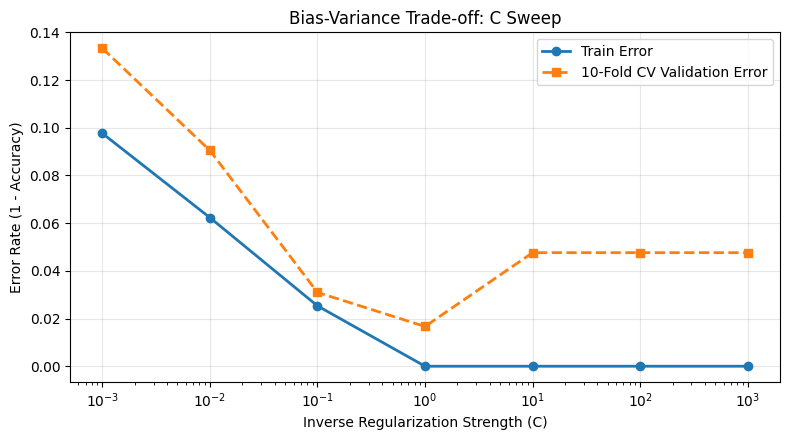

In [328]:
plot_bias_variance_c(grid_search_best_model_lock_pen_pca)

=== Best Logistic Regression Hyperparameters ===  
logreg__C: 1.0  
logreg__penalty: l2  
pca__n_components: 7  

Best 10-Fold CV Accuracy: 0.9833  

=== Final Test Set Evaluation (Logistic Regression) ===  
Test Accuracy:    1.0000  
Test Macro F1:   1.0000    

bias-variance analysis against c while locking pca n components (7) and penalty (l2) given from the best model hyperprms above: train error is high at small values of c because of underfitting (high bias). as c gets bigger (less regularization), training error drops to zero because weak regularization allows the model to fit the data extremely closely, eventually capturing noise "following the noise" (overfitting). the 10-fold cv validation error displays a classic u-shape: at low c values (simpler model due to strong regularization), error is high because the model suffers from underfitting (high bias). as c increases and regularization weakens, the model reaches the sweet spot at c = 1.0 where validation error hits its minimum, meaning it will generalize best on new unseen data. as c continues to grow, model complexity increases due to weaker regularization, causing test validation error to climb back up due to overfitting.

In [329]:

import matplotlib.pyplot as plt
import pandas as pd


def plot_bias_variance_pca(grid_search):
  """Plots Train vs 10-Fold CV Error as a function of PCA components.

  Expects param_grid varying 'pca__n_components' (e.g. range(1, 11)).
  """
  df = pd.DataFrame(grid_search.cv_results_)

  # Extract PCA values and sort
  df['pca'] = pd.to_numeric(df['param_pca__n_components'])
  df = df.sort_values('pca')

  pca_vals = df['pca'].values
  train_err = 1.0 - df['mean_train_score'].values
  cv_err = 1.0 - df['mean_test_score'].values

  # Plotting
  plt.figure(figsize=(8, 4.5))
  plt.plot(
      pca_vals, train_err, 'o-', lw=2, color='tab:blue', label='Train Error'
  )
  plt.plot(
      pca_vals,
      cv_err,
      's--',
      lw=2,
      color='tab:orange',
      label='10-Fold CV Validation Error',
  )

  plt.xticks(pca_vals)
  plt.xlabel('Number of Principal Components (PCA)')
  plt.ylabel('Error Rate (1 - Accuracy)')
  plt.title('Bias-Variance Trade-off: PCA Sweep')
  plt.legend(loc='best')
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

In [330]:
grid_search_best_model.best_params_

{'logreg__C': 1.0, 'logreg__penalty': 'l2', 'pca__n_components': 7}

In [331]:
prm_grd_best_model_lock_c_pen = {
    'logreg__C': [logreg__C],
    'logreg__penalty': [logreg__penalty],
    'pca__n_components': range(1, 11)
}

In [332]:
grid_search_best_model_lock_pen_c = run_lg(prm_grd_best_model_lock_c_pen, RAND);

=== Best Logistic Regression Hyperparameters ===
logreg__C: 1.0
logreg__penalty: l2
pca__n_components: 7

Best 10-Fold CV Accuracy: 0.9833

=== Final Test Set Evaluation (Logistic Regression) ===
Test Accuracy:    1.0000


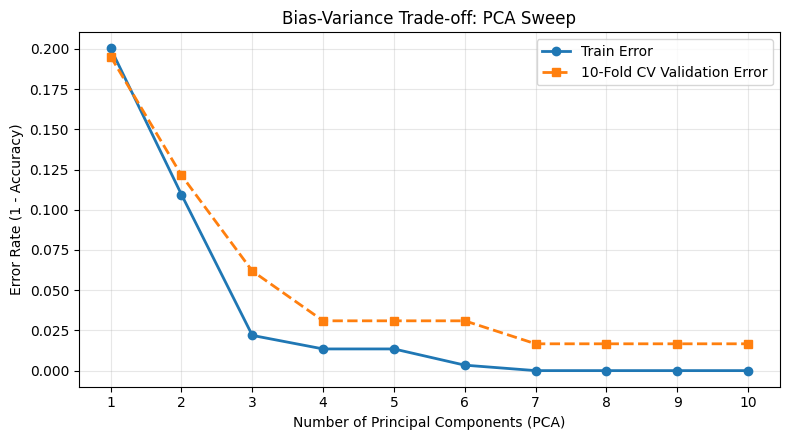

In [333]:
plot_bias_variance_pca(grid_search_best_model_lock_pen_c)

In [334]:
evr = pca.explained_variance_ratio_
cum_var = np.cumsum(evr)
pc4_cum = cum_var[3]
pc6_cum = cum_var[5]

pc4_cum, pc6_cum

(np.float64(0.9469845900916314), np.float64(0.9842342959478011))

bias-variance analysis against pc while locking penalty l2) and c (1) given from the best model:
unlike the c sweep, the validation error curve does not show a classic u-shape (it flatens at pc 4 with additional insignificant drop moving from pc6 to pc7). going from left to right (pc1 to pc10) goes from being too simple sufering from high bias becouse of lack in information resulting in underfiting and high validation error. still becouse pc1 captures 67.5% of the explained variance, the validation error is he highest but not so bad to begin with only with 1D (0.2), then, there is a big drop moving from pc1 to pc2 and pc3 reflecting a big addition in the meaningful information (that is moving form 67.5% to 80% cumulative var with pc2 and to 90% cumulative variance with pc3), anthor smaller drop in the validation error acheaved moving from pc3 to pc4 with 94.6% of the explained variance. generally speaking, from this point on (except the insignificant drop from pc6 to pc7) there is no improvment in the validation error when adding more pcs to the model, and the model flatens. so the model was suffering from underfitting at the begining, then we get the sweetspot around pc4 or pc7, but the validation error is not going up from this point and it seems that it is not suffering from overfiting as adding more complexcity to the model with more pcs. this can be explained maby because pca is implicit regularizer (by mitigating multicolinearity problem), so it capturing more of the underling predictive information and less from the noise, and by doing so it reduces the noise, so essentialy when adding more pcs to the model, yes the model is more complex but "without the noise" that usually complexcity brings along with, so the modle does not seem to be suffering from overfiting.  

conclusion:  
although pc7 has the lowest validation error and methodologicaly will generalize best, i would still go with pc3 or pc4 in production environment. pc3 or pc4 gets a realy good validation test score, and the gain of using pc7 in the validation score is insignificant. so if we consider the parsimony principal, pc3 or pc4 will ahceaving high preformence while reducing the risk of adding unesseary complexcity.

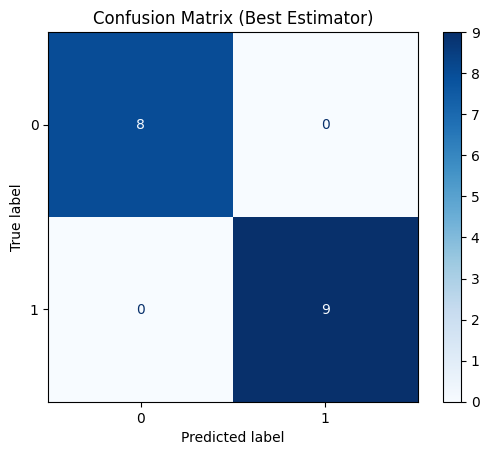

In [335]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


def plt_cm(grid_search, X_test, y_test, labels=None):
  best_model = grid_search.best_estimator_
  y_pred = best_model.predict(X_test)

  cm = confusion_matrix(y_test, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues")
  plt.title("Confusion Matrix (Best Estimator)")
  plt.grid(False)
  plt.show()

  return cm


cm_array = plt_cm(grid_search_best_model, X_test, y_test)

In [336]:
print('thx')

thx
